In [548]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from windrose import WindroseAxes
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

## DPW Supervised Learning

In [549]:
dpw_final = pd.read_csv("final PM data/dpw_final_pm25.csv")
dpw_final = dpw_final.sort_values("datetime_utc").reset_index(drop=True)
dpw_final.head()

,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0
1,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0
2,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0
3,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0
4,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0


In [550]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(dpw_final.iloc[train_start:train_end])
    val_dfs.append(dpw_final.iloc[val_start:val_end])
    test_dfs.append(dpw_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [551]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [552]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 4.027773857116699 Validation Accuracy: 0.29132792353630066
Epoch: 100 Loss: 1.2343437671661377 Validation Accuracy: 0.38211381435394287
Epoch: 200 Loss: 1.0148415565490723 Validation Accuracy: 0.5081300735473633
Epoch: 300 Loss: 0.9138736724853516 Validation Accuracy: 0.565040647983551
Epoch: 400 Loss: 0.8370321989059448 Validation Accuracy: 0.6111111044883728
Epoch: 500 Loss: 0.7708152532577515 Validation Accuracy: 0.6382113695144653
Epoch: 600 Loss: 0.7184674143791199 Validation Accuracy: 0.6639566421508789
Epoch: 700 Loss: 0.6883158683776855 Validation Accuracy: 0.6869918704032898
Epoch: 800 Loss: 0.667407751083374 Validation Accuracy: 0.6910569071769714
Epoch: 900 Loss: 0.6538198590278625 Validation Accuracy: 0.6937669515609741


In [553]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7425474524497986


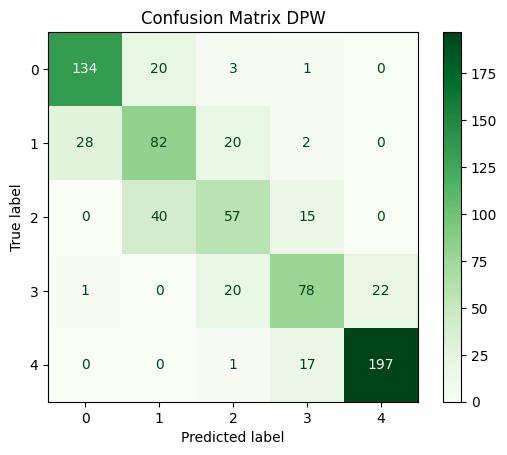

In [554]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix DPW")
plt.show()

In [555]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       158
           1       0.58      0.62      0.60       132
           2       0.56      0.51      0.54       112
           3       0.69      0.64      0.67       121
           4       0.90      0.92      0.91       215

    accuracy                           0.74       738
   macro avg       0.71      0.71      0.71       738
weighted avg       0.74      0.74      0.74       738



## PEMA Supervised Learning

In [556]:
pema_final = pd.read_csv("final PM data/pema_final_pm25.csv")
pema_final = pema_final.sort_values("datetime_utc").reset_index(drop=True)
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0


In [557]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(pema_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pema_final.iloc[train_start:train_end])
    val_dfs.append(pema_final.iloc[val_start:val_end])
    test_dfs.append(pema_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [558]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [559]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.8216350078582764 Validation Accuracy: 0.2348484843969345
Epoch: 100 Loss: 1.0173419713974 Validation Accuracy: 0.46666666865348816
Epoch: 200 Loss: 0.8017650842666626 Validation Accuracy: 0.5560606122016907
Epoch: 300 Loss: 0.68990558385849 Validation Accuracy: 0.6303030252456665
Epoch: 400 Loss: 0.6240662932395935 Validation Accuracy: 0.6772727370262146
Epoch: 500 Loss: 0.5851867198944092 Validation Accuracy: 0.7151514887809753
Epoch: 600 Loss: 0.5608086585998535 Validation Accuracy: 0.7348484992980957
Epoch: 700 Loss: 0.5441854596138 Validation Accuracy: 0.7515151500701904
Epoch: 800 Loss: 0.5323838591575623 Validation Accuracy: 0.75
Epoch: 900 Loss: 0.5213569402694702 Validation Accuracy: 0.7530303001403809


In [560]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7333333492279053


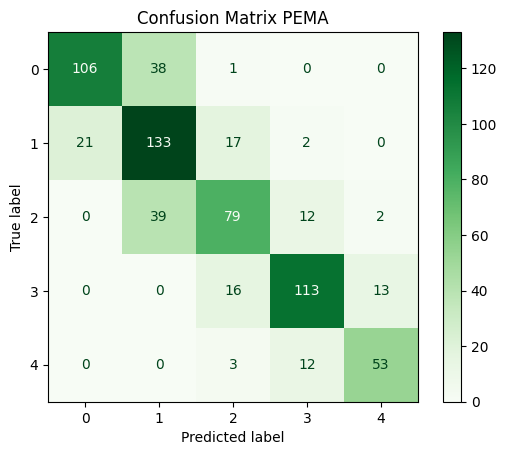

In [561]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PEMA")
plt.show()

In [562]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78       145
           1       0.63      0.77      0.69       173
           2       0.68      0.60      0.64       132
           3       0.81      0.80      0.80       142
           4       0.78      0.78      0.78        68

    accuracy                           0.73       660
   macro avg       0.75      0.73      0.74       660
weighted avg       0.74      0.73      0.73       660



## PHA Supervised Learning

In [563]:
pha_final = pd.read_csv("final PM data/pha_final_pm25.csv")
pha_final = pha_final.sort_values("datetime_utc").reset_index(drop=True)
pha_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,62.023333,3.330000,261.698333,2.648500,0.207967,2.620748,0.382404,6,1.000000,6.123234e-17,0.165667,0.168467,0.198267,0.389583,0
1,2025-01-02 07:00:00+00:00,58.768333,3.020000,270.975000,2.878667,0.295167,2.878250,-0.048984,7,0.965926,-2.588190e-01,0.207967,0.165667,0.168467,0.214200,0
2,2025-01-02 08:00:00+00:00,55.421667,2.898333,273.275000,2.903833,0.309267,2.899091,-0.165891,8,0.866025,-5.000000e-01,0.295167,0.207967,0.165667,0.192533,0
3,2025-01-02 09:00:00+00:00,53.240000,2.845000,273.426667,2.866000,0.312800,2.860876,-0.171304,9,0.707107,-7.071068e-01,0.309267,0.295167,0.207967,0.198267,0
4,2025-01-02 10:00:00+00:00,52.566667,2.850000,266.546667,2.758667,0.346200,2.753657,0.166170,10,0.500000,-8.660254e-01,0.312800,0.309267,0.295167,0.168467,0


In [564]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pha_final.iloc[train_start:train_end])
    val_dfs.append(pha_final.iloc[val_start:val_end])
    test_dfs.append(pha_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [565]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [566]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.4722321033477783 Validation Accuracy: 0.21815718710422516
Epoch: 100 Loss: 1.1547859907150269 Validation Accuracy: 0.4390243887901306
Epoch: 200 Loss: 0.9142899513244629 Validation Accuracy: 0.5799458026885986
Epoch: 300 Loss: 0.7585047483444214 Validation Accuracy: 0.6775068044662476
Epoch: 400 Loss: 0.6319512724876404 Validation Accuracy: 0.7317073345184326
Epoch: 500 Loss: 0.565087616443634 Validation Accuracy: 0.7642276287078857
Epoch: 600 Loss: 0.5309808254241943 Validation Accuracy: 0.7601625919342041
Epoch: 700 Loss: 0.5074349641799927 Validation Accuracy: 0.7628726363182068
Epoch: 800 Loss: 0.48700132966041565 Validation Accuracy: 0.7520325183868408
Epoch: 900 Loss: 0.4760861396789551 Validation Accuracy: 0.7506775259971619


In [567]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7628726363182068


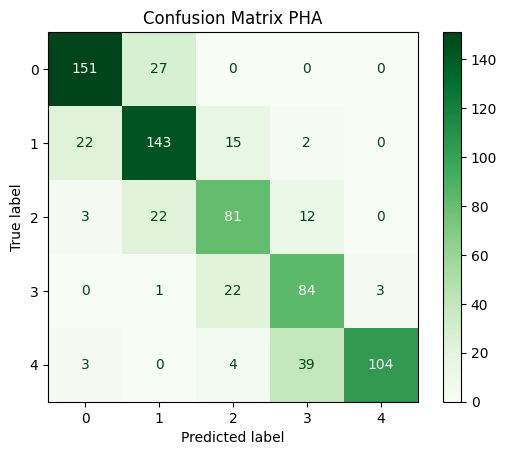

In [568]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PHA")
plt.show()

In [569]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       178
           1       0.74      0.79      0.76       182
           2       0.66      0.69      0.68       118
           3       0.61      0.76      0.68       110
           4       0.97      0.69      0.81       150

    accuracy                           0.76       738
   macro avg       0.77      0.76      0.75       738
weighted avg       0.78      0.76      0.77       738

